# 🎮 1D Playground: Diffusion & Flow Matching Sanity Checks

This notebook provides interactive 1D experiments to build intuition for diffusion models and flow matching.

**Why 1D?**
- Ultra-fast training (in seconds & CPU friendly)
- Easy to visualize distributions and flows
- Perfect for debugging and understanding

**Note:** You should be able to use this notebook with CPU only machines.

If you are using VSCode and you do not see your venv in the kernel options, first activate your venv in your terminal and run 

'''

uv run --active python -m ipykernel install --user --name cmu-10799 --display-name "Python (cmu-10799)"

'''

In VS Code:
- Command Palette → Python: Select Interpreter → pick .venv-(your env)/bin/python
- In the notebook → Select Kernel → pick .venv-(your env) or Python (cmu-10799-cpu)

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import wasserstein_distance
from tqdm.notebook import tqdm

plt.style.use("default")
%matplotlib inline
%config InlineBackend.figure_format = "retina"

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
code_root = Path.cwd() if (Path.cwd() / "train.py").exists() else Path.cwd().parent
asset_dir = code_root.parent / "docs/hw1/.assets"
asset_dir.mkdir(parents=True, exist_ok=True)
print(f"Using device: {device}")
print(f"Random seed: {seed}")

Using device: cuda
Random seed: 42


## 1. Create 1D Mixture of Gaussians

In [2]:
def get_1d_data(name, n_samples=10000):
    """Generate 1D mixture of Gaussians datasets with different weights."""
    if name == '2gaussians':
        # Two Gaussians at -2 and 2 (equal weights)
        centers = [-2.0, 2.0]
        std = 0.3
        weights = [0.5, 0.5]
    elif name == '3gaussians':
        # Three Gaussians at -2, 0, 2 (equal weights)
        centers = [-2.0, 0.0, 2.0]
        std = 0.3
        weights = [1/3, 1/3, 1/3]
    elif name == '5gaussians':
        # Five evenly spaced Gaussians (equal weights)
        centers = [-3.0, -1.5, 0.0, 1.5, 3.0]
        std = 0.25
        weights = [0.2, 0.2, 0.2, 0.2, 0.2]
    elif name == 'uneven':
        # Uneven mixture with different spacing (equal weights)
        centers = [-3.5, -1.0, 0.5, 2.5]
        std = 0.3
        weights = [0.25, 0.25, 0.25, 0.25]
    elif name == 'wide':
        # Wider Gaussians (equal weights)
        centers = [-2.0, 2.0]
        std = 0.8
        weights = [0.5, 0.5]
    elif name == 'weighted2':
        # Two Gaussians with different weights (tall left, short right)
        centers = [-2.0, 2.0]
        std = 0.3
        weights = [0.8, 0.2]
    elif name == 'weighted3':
        # Three Gaussians with different weights (tall-short-medium)
        centers = [-2.5, 0.0, 2.5]
        std = 0.3
        weights = [0.5, 0.2, 0.3]
    elif name == 'weighted5':
        # Five Gaussians with varied weights
        centers = [-3.0, -1.5, 0.0, 1.5, 3.0]
        std = 0.25
        weights = [0.1, 0.15, 0.4, 0.25, 0.1]
    elif name == 'weighted_wide':
        # Wider Gaussians (unequal weights)
        centers = [-2.0, 2.0]
        std = 0.8
        weights = [0.65, 0.35]
    else:
        raise ValueError(f"Unknown dataset: {name}")
    
    # Normalize weights
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Sample from each Gaussian according to weights
    X = []
    for center, weight in zip(centers, weights):
        n_samples_for_center = int(n_samples * weight)
        samples = np.random.randn(n_samples_for_center, 1) * std + center
        X.append(samples)
    X = np.concatenate(X, axis=0)
    
    # Shuffle
    np.random.shuffle(X)
    
    return torch.tensor(X, dtype=torch.float32)


def get_ground_truth_density(name, x_values):
    """Compute the ground truth density for a given dataset at x_values."""
    if name == '2gaussians':
        centers = [-2.0, 2.0]
        std = 0.3
        weights = [0.5, 0.5]
    elif name == '3gaussians':
        centers = [-2.0, 0.0, 2.0]
        std = 0.3
        weights = [1/3, 1/3, 1/3]
    elif name == '5gaussians':
        centers = [-3.0, -1.5, 0.0, 1.5, 3.0]
        std = 0.25
        weights = [0.2, 0.2, 0.2, 0.2, 0.2]
    elif name == 'uneven':
        centers = [-3.5, -1.0, 0.5, 2.5]
        std = 0.3
        weights = [0.25, 0.25, 0.25, 0.25]
    elif name == 'wide':
        centers = [-2.0, 2.0]
        std = 0.8
        weights = [0.5, 0.5]
    elif name == 'weighted2':
        centers = [-2.0, 2.0]
        std = 0.3
        weights = [0.8, 0.2]
    elif name == 'weighted3':
        centers = [-2.5, 0.0, 2.5]
        std = 0.3
        weights = [0.5, 0.2, 0.3]
    elif name == 'weighted5':
        centers = [-3.0, -1.5, 0.0, 1.5, 3.0]
        std = 0.25
        weights = [0.1, 0.15, 0.4, 0.25, 0.1]
    elif name == 'weighted_wide':
        centers = [-2.0, 2.0]
        std = 0.8
        weights = [0.65, 0.35]
    else:
        raise ValueError(f"Unknown dataset: {name}")
    
    # Normalize weights
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Compute mixture of Gaussians density
    density = np.zeros_like(x_values)
    for center, weight in zip(centers, weights):
        density += weight * (1.0 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_values - center) / std) ** 2)
    
    return density

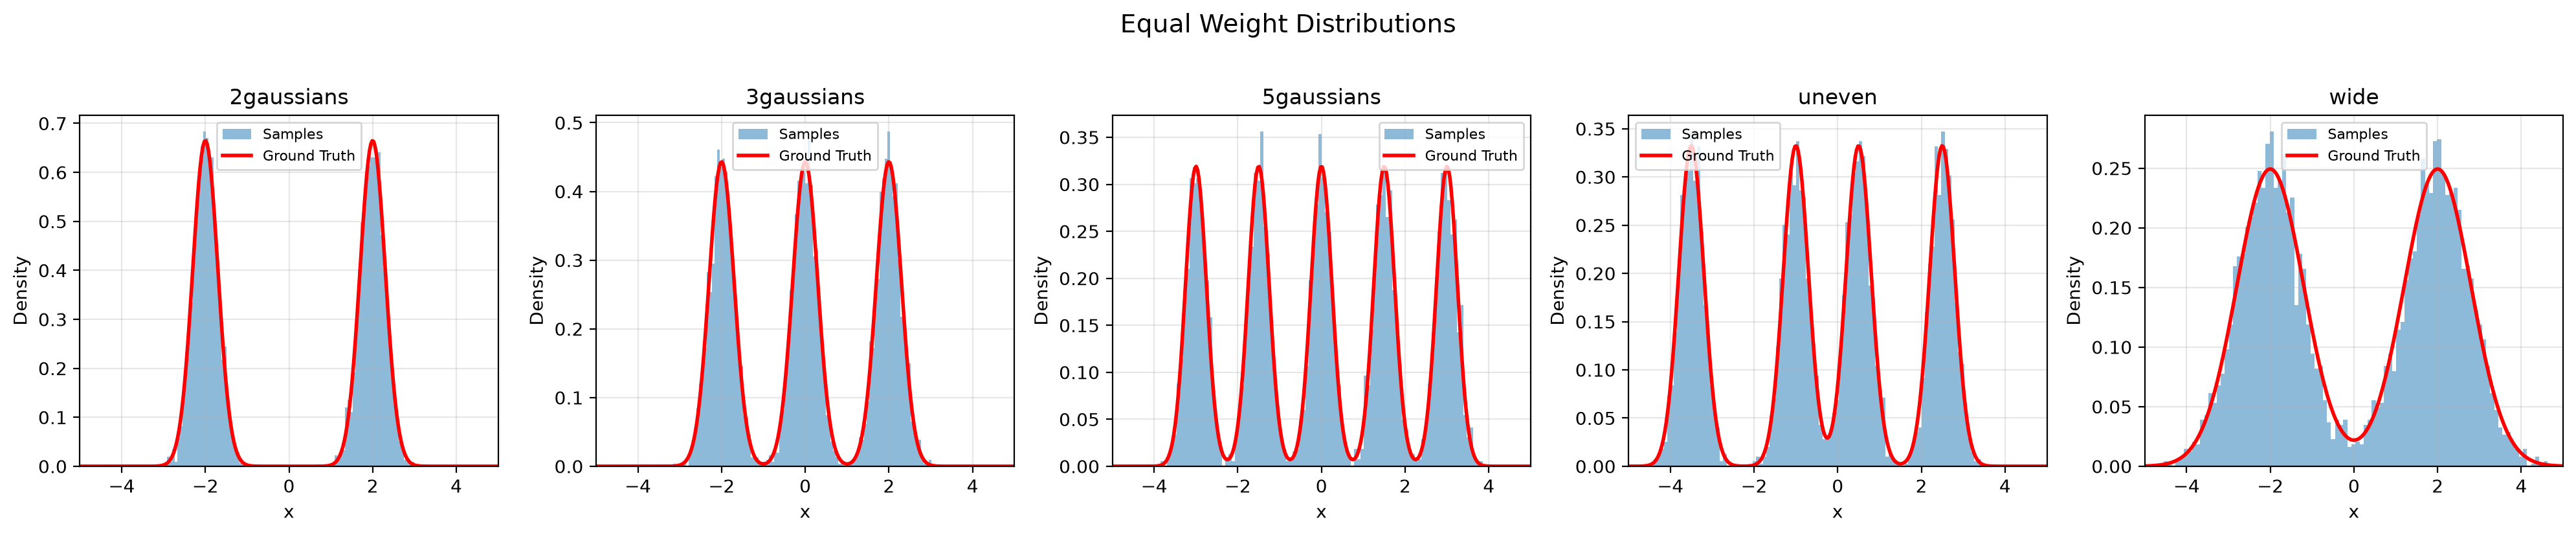

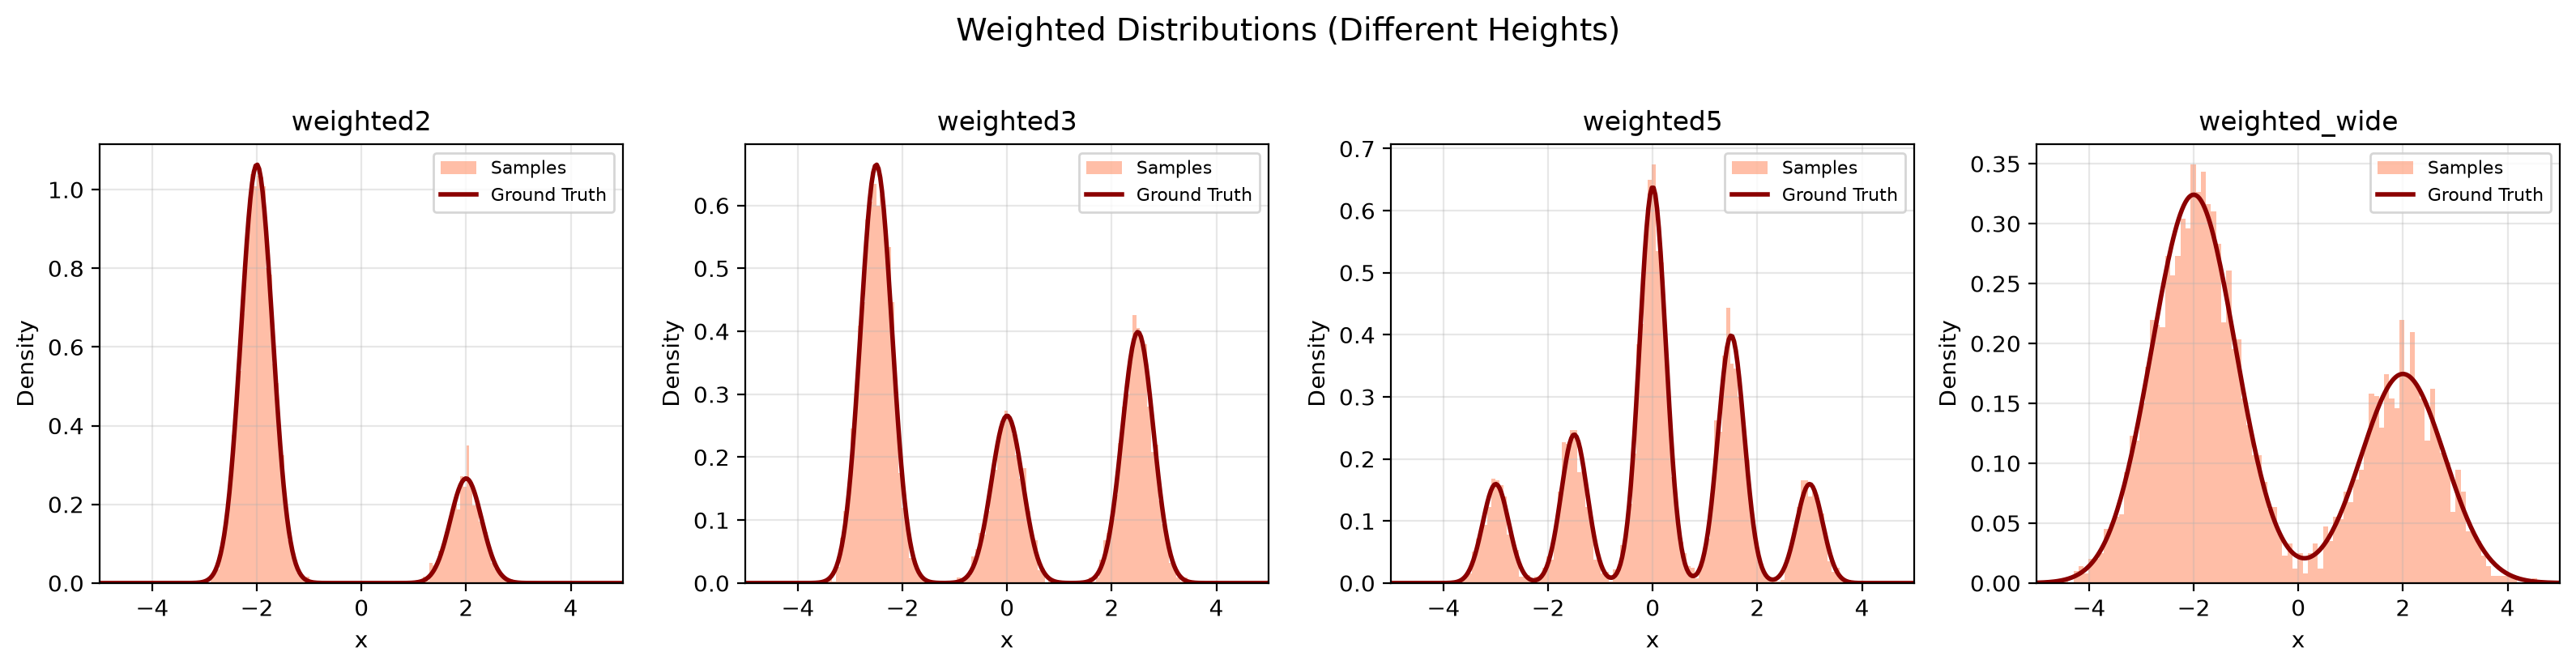

In [3]:
# Visualize available distributions
datasets_equal = ['2gaussians', '3gaussians', '5gaussians', 'uneven', 'wide']
datasets_weighted = ['weighted2', 'weighted3', 'weighted5', 'weighted_wide']

# Plot equal weight distributions
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Equal Weight Distributions', fontsize=14, y=1.02)
for ax, name in zip(axes, datasets_equal):
    data = get_1d_data(name, n_samples=5000)
    ax.hist(data.numpy(), bins=100, density=True, alpha=0.5, label='Samples')
    
    # Overlay ground truth
    x_line = np.linspace(-5, 5, 300)
    density = get_ground_truth_density(name, x_line)
    ax.plot(x_line, density, 'r-', linewidth=2, label='Ground Truth')
    
    ax.set_title(name)
    ax.set_xlim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Plot weighted distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Weighted Distributions (Different Heights)', fontsize=14, y=1.02)
for ax, name in zip(axes, datasets_weighted):
    data = get_1d_data(name, n_samples=5000)
    ax.hist(data.numpy(), bins=100, density=True, alpha=0.5, color='coral', label='Samples')
    
    # Overlay ground truth
    x_line = np.linspace(-5, 5, 300)
    density = get_ground_truth_density(name, x_line)
    ax.plot(x_line, density, 'darkred', linewidth=2, label='Ground Truth')
    
    ax.set_title(name)
    ax.set_xlim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Simple network for 1D

First design a simple network (like an MLP) to model the 1D data, remember to also include the time embeddings.

In [4]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim=32):
        super().__init__()
        if dim % 2 != 0:
            raise ValueError("Embedding dimension must be even")
        half_dim = dim // 2
        frequencies = torch.exp(
            -np.log(10000) * torch.arange(half_dim, dtype=torch.float32) / half_dim
        )
        self.register_buffer("frequencies", frequencies)

    def forward(self, timesteps):
        angles = timesteps.float()[:, None] * self.frequencies[None, :]
        return torch.cat([angles.sin(), angles.cos()], dim=-1)


class Denoiser1D(nn.Module):
    def __init__(self, time_dim=32, hidden_dim=128):
        super().__init__()
        self.time_embedding = SinusoidalTimeEmbedding(time_dim)
        self.network = nn.Sequential(
            nn.Linear(1 + time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x, timesteps):
        time_features = self.time_embedding(timesteps)
        return self.network(torch.cat([x, time_features], dim=-1))


model = Denoiser1D().to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Trainable parameters: 37,505


## 3. DDPM algorithm implementation

Implement the forward process, backward process, loss calculation and the sampling process of the DDPM algorithm. You can feel free to follow the structure of src/methods/ddpm.py or directly import your implementation from there.

In [5]:
class DDPM1D:
    def __init__(self, model, num_timesteps=100, beta_start=1e-4, beta_end=2e-2):
        self.model = model
        self.num_timesteps = num_timesteps
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.alpha_bars_previous = torch.cat(
            [torch.ones(1, device=device), self.alpha_bars[:-1]]
        )
        self.posterior_variance = (
            self.betas * (1.0 - self.alpha_bars_previous) / (1.0 - self.alpha_bars)
        ).clamp(min=1e-20)

    @staticmethod
    def _extract(values, timesteps):
        return values[timesteps].reshape(-1, 1)

    def forward_process(self, x_0, timesteps, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        sqrt_alpha_bar = self._extract(self.alpha_bars.sqrt(), timesteps)
        sqrt_one_minus_alpha_bar = self._extract(
            (1.0 - self.alpha_bars).sqrt(), timesteps
        )
        x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise
        return x_t, noise

    def loss(self, x_0):
        timesteps = torch.randint(
            0, self.num_timesteps, (x_0.shape[0],), device=x_0.device
        )
        x_t, noise = self.forward_process(x_0, timesteps)
        predicted_noise = self.model(x_t, timesteps)
        return F.mse_loss(predicted_noise, noise)

    @torch.no_grad()
    def reverse_process(self, x_t, timesteps):
        beta_t = self._extract(self.betas, timesteps)
        alpha_t = self._extract(self.alphas, timesteps)
        alpha_bar_t = self._extract(self.alpha_bars, timesteps)
        predicted_noise = self.model(x_t, timesteps)
        mean = (x_t - beta_t * predicted_noise / (1.0 - alpha_bar_t).sqrt()) / alpha_t.sqrt()
        variance = self._extract(self.posterior_variance, timesteps)
        noise = torch.randn_like(x_t)
        nonzero_mask = (timesteps > 0).float().reshape(-1, 1)
        return mean + nonzero_mask * variance.sqrt() * noise

    @torch.no_grad()
    def sample(self, num_samples, keep_trajectory=False):
        self.model.eval()
        x = torch.randn(num_samples, 1, device=device)
        trajectory = [x.detach().cpu()]
        for step in reversed(range(self.num_timesteps)):
            timesteps = torch.full((num_samples,), step, device=device, dtype=torch.long)
            x = self.reverse_process(x, timesteps)
            if keep_trajectory:
                trajectory.append(x.detach().cpu())
        return x.detach().cpu(), trajectory


ddpm = DDPM1D(model)
print(f"DDPM timesteps: {ddpm.num_timesteps}")

DDPM timesteps: 100


## 4. Training

Write your training loop here (or you can combine it above, whichever way is easier for you)

Training 1D DDPM:   0%|          | 0/5000 [00:00<?, ?it/s]

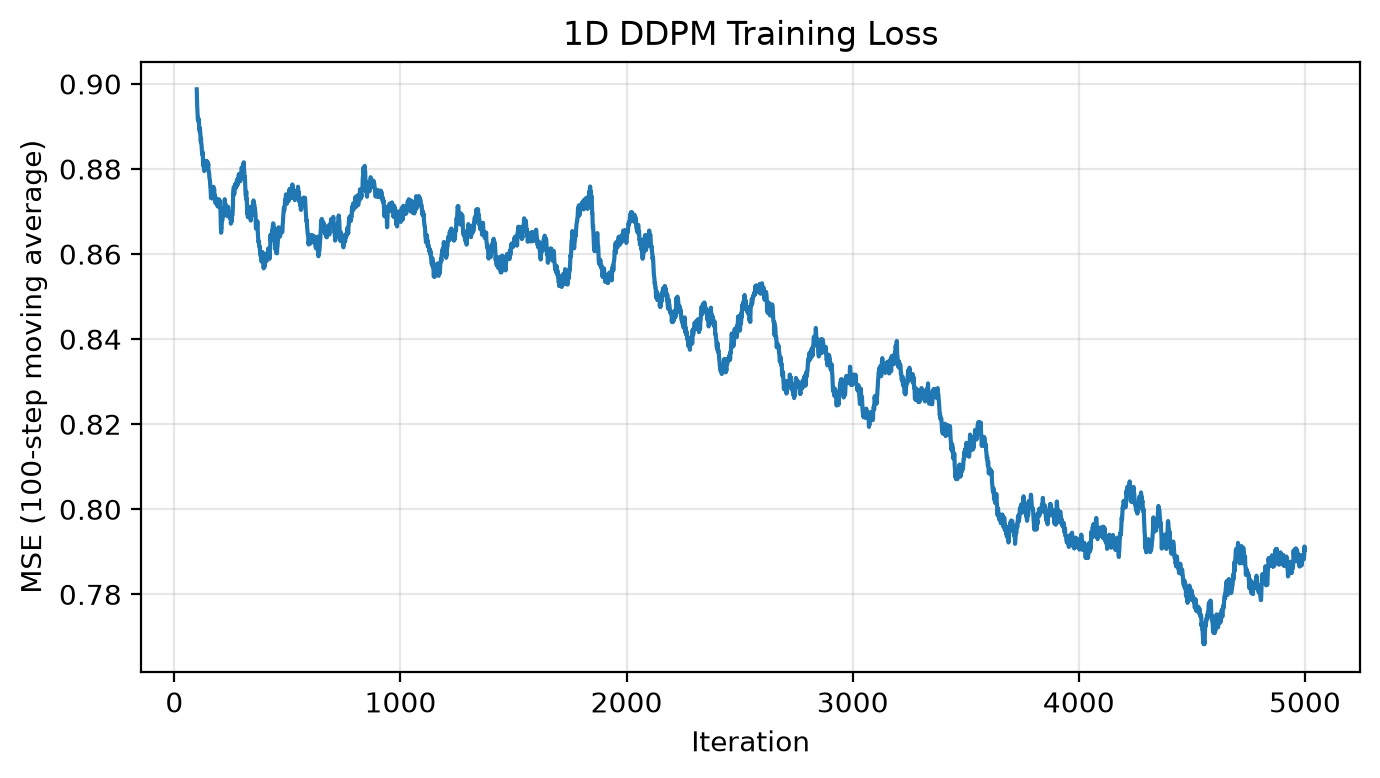

Initial mean loss: 0.8987
Final mean loss: 0.7904


In [6]:
dataset_name = "weighted5"
train_data = get_1d_data(dataset_name, n_samples=20000).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
num_iterations = 5000
batch_size = 512
losses = []

model.train()
progress = tqdm(range(num_iterations), desc="Training 1D DDPM")
for step in progress:
    indices = torch.randint(0, train_data.shape[0], (batch_size,), device=device)
    batch = train_data[indices]
    loss = ddpm.loss(batch)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (step + 1) % 250 == 0:
        recent_loss = np.mean(losses[-250:])
        progress.set_postfix(loss=f"{recent_loss:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
window = 100
smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
ax.plot(np.arange(window - 1, num_iterations), smoothed)
ax.set(title="1D DDPM Training Loss", xlabel="Iteration", ylabel="MSE (100-step moving average)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(asset_dir / "homework1-q3-1d-loss.png", dpi=160)
plt.show()
print(f"Initial mean loss: {np.mean(losses[:100]):.4f}")
print(f"Final mean loss: {np.mean(losses[-100:]):.4f}")

## 5. Visualize Samples

Visualize your learned distributions and compare them with the ground truth. I have left my visualization results for you as reference.

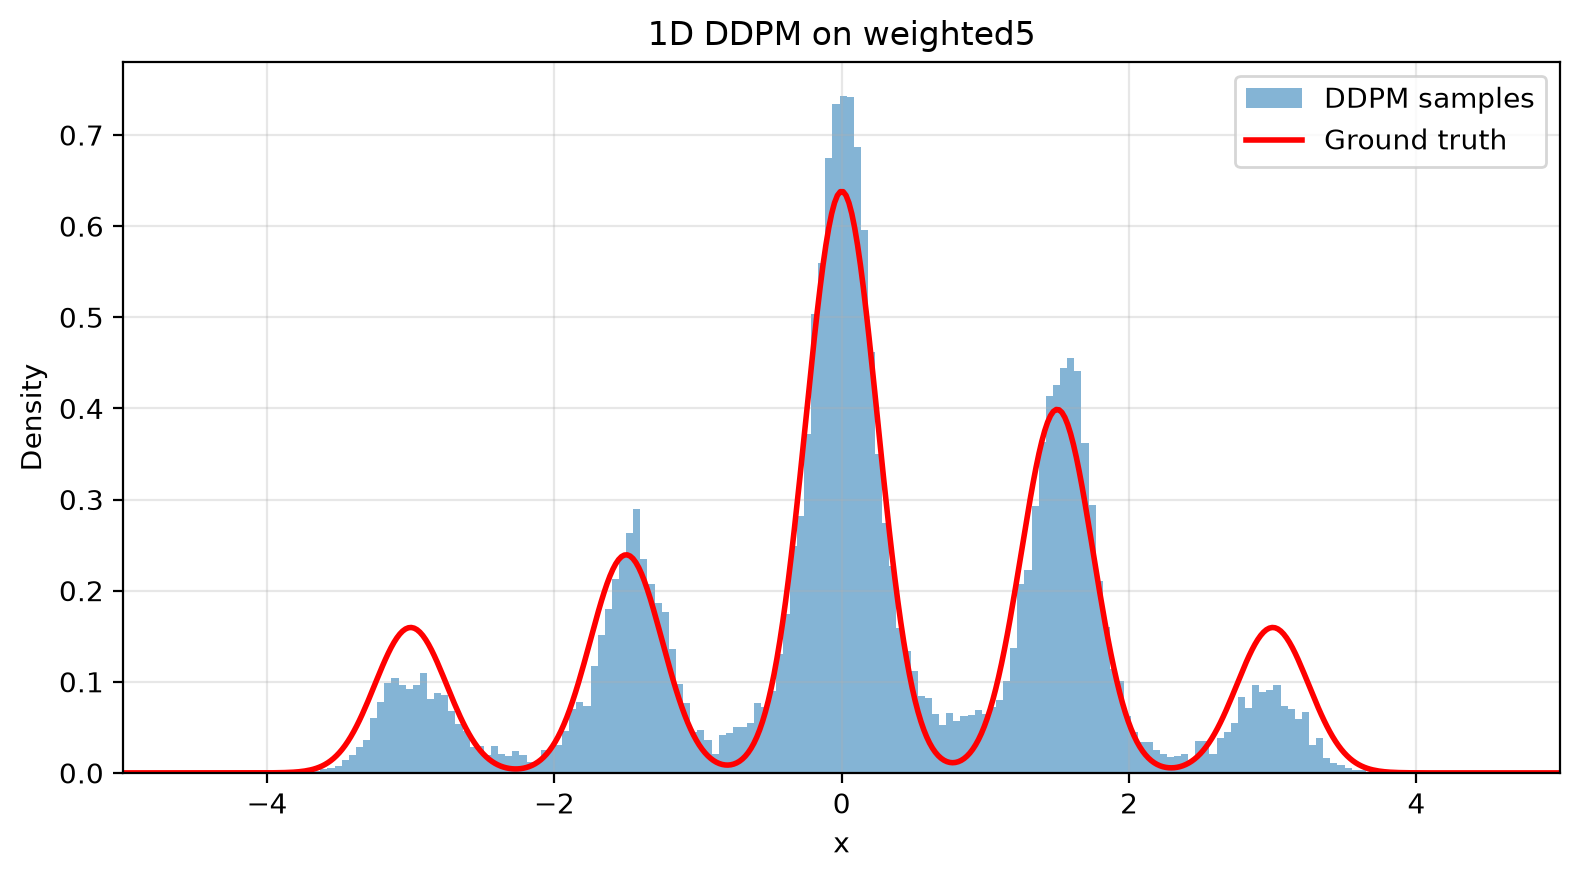

Target mode weights:    [0.1  0.15 0.4  0.25 0.1 ]
Generated mode weights: [0.071 0.159 0.439 0.271 0.06 ]
Wasserstein-1 distance: 0.1696


In [7]:
generated, trajectory = ddpm.sample(20000, keep_trajectory=True)
generated_np = generated.squeeze(1).numpy()
reference_np = get_1d_data(dataset_name, n_samples=20000).squeeze(1).numpy()
x_line = np.linspace(-5, 5, 500)
ground_truth = get_ground_truth_density(dataset_name, x_line)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(generated_np, bins=150, density=True, alpha=0.55, label="DDPM samples")
ax.plot(x_line, ground_truth, "r-", linewidth=2, label="Ground truth")
ax.set(xlim=(-5, 5), xlabel="x", ylabel="Density", title="1D DDPM on weighted5")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(asset_dir / "homework1-q3-1d-distribution.png", dpi=160)
plt.show()

boundaries = np.array([-2.25, -0.75, 0.75, 2.25])
generated_weights = np.bincount(np.digitize(generated_np, boundaries), minlength=5) / len(generated_np)
target_weights = np.array([0.10, 0.15, 0.40, 0.25, 0.10])
w_distance = wasserstein_distance(reference_np, generated_np)
print(f"Target mode weights:    {np.round(target_weights, 3)}")
print(f"Generated mode weights: {np.round(generated_weights, 3)}")
print(f"Wasserstein-1 distance: {w_distance:.4f}")

## 6. Visualize Sampling Trajectories

Besides visualizing the final results, you can also visualize the entire sampling trajectory in order to get a better understanding of the process. Here I also left you my visualization results as an example.

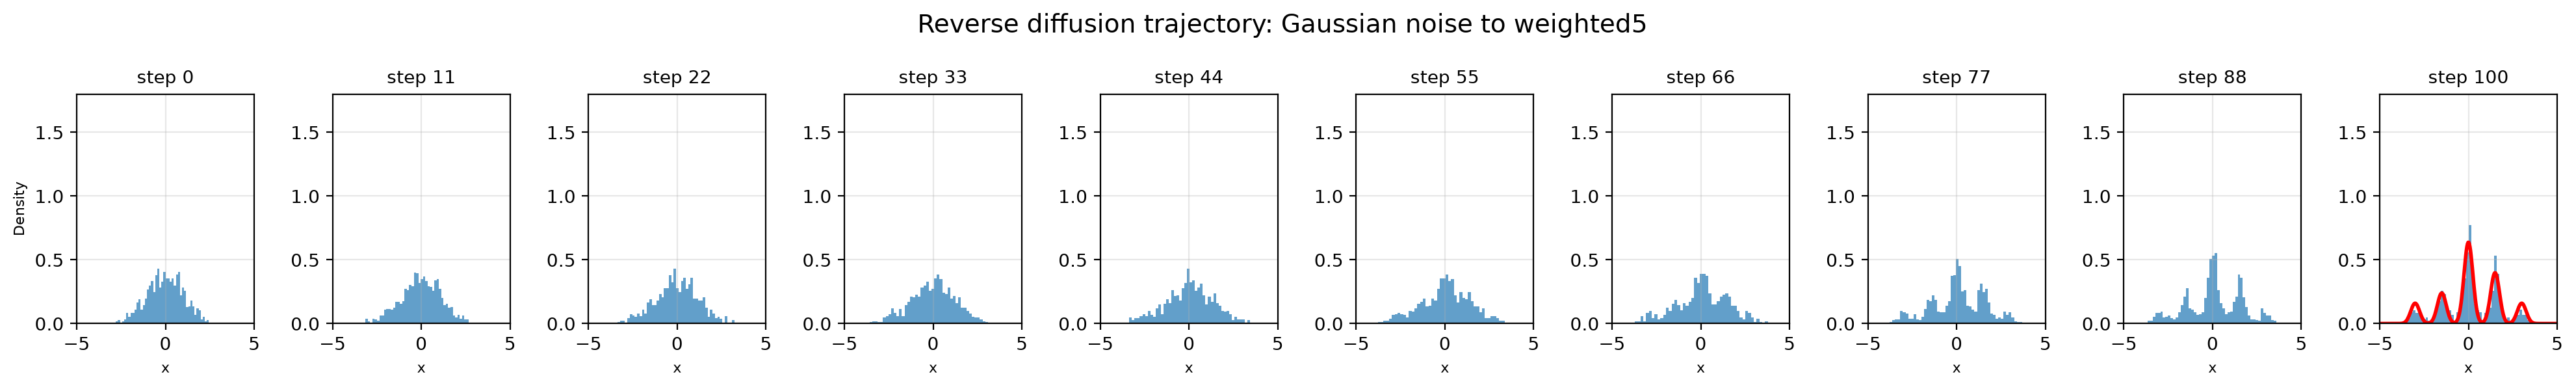

In [8]:
def plot_trajectory(trajectory, title, n_points=1000, n_steps_show=10, dataset_name=None):
    """Plot selected states from noise to generated data."""
    step_indices = np.linspace(0, len(trajectory) - 1, n_steps_show, dtype=int)
    fig, axes = plt.subplots(1, n_steps_show, figsize=(2 * n_steps_show, 3))
    x_line = np.linspace(-5, 5, 300)
    ground_truth = (
        get_ground_truth_density(dataset_name, x_line) if dataset_name is not None else None
    )

    for position, (ax, step_idx) in enumerate(zip(axes, step_indices)):
        points = trajectory[step_idx][:n_points]
        ax.hist(points.numpy(), bins=50, density=True, alpha=0.7)
        if ground_truth is not None and position == len(step_indices) - 1:
            ax.plot(x_line, ground_truth, "r-", linewidth=2)
        ax.set_xlim(-5, 5)
        ax.set_ylim(0, 1.8)
        ax.set_title(f"step {step_idx}", fontsize=10)
        ax.set_xlabel("x", fontsize=8)
        if position == 0:
            ax.set_ylabel("Density", fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    fig.savefig(asset_dir / "homework1-q3-1d-trajectory.png", dpi=160)
    plt.show()


plot_trajectory(
    trajectory,
    "Reverse diffusion trajectory: Gaussian noise to weighted5",
    dataset_name=dataset_name,
)